# AI4EO — Land-Cover Classification of Sentinel-2 Imagery (EuroSAT)

**An *AI for Earth Observation* project.** This notebook runs the full pipeline end-to-end:

1. **Problem** — classify Sentinel-2 image patches into 10 land-cover classes (the EuroSAT benchmark).
2. **Remote-sensing technique** — optical multispectral imaging with Sentinel-2 (schematic).
3. **AI algorithm** — *unsupervised* (K-means, Gaussian Mixture Model) **and** *supervised* (Random Forest, a compact CNN).
4. **Evaluation** — clustering metrics, confusion matrices, a head-to-head comparison.
5. **Environmental cost** — energy + CO₂ estimate for this very run.

All heavy lifting lives in the documented `src/` package; this notebook orchestrates and explains it.
Detailed write-ups are in `docs/` and `report/REPORT.md`.

> **Tip:** `Kernel → Restart & Run All`. First run downloads EuroSAT (~94 MB) and caches it.
> No internet / no GPU? Set `FORCE_SYNTHETIC = True` below — the identical pipeline runs on synthetic data.

## 0. Setup

In [ ]:
%matplotlib inline
import sys, os, time, json
from pathlib import Path

# Make the repo root importable and the working directory, whether this
# notebook is launched from the repo root or from notebooks/.
here = Path.cwd()
ROOT = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print("Working directory:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src import EUROSAT_CLASSES, data, features, unsupervised, supervised, evaluate, carbon, figures

# ---- experiment configuration -------------------------------------------------
SEED          = 42
N_PER_CLASS   = 400      # images sampled per class (None = all 27,000)
CNN_EPOCHS    = 20       # CPU-friendly
FORCE_SYNTHETIC = False  # True -> run fully offline on synthetic data

Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
np.random.seed(SEED)
timings = {}   # collect per-step wall-clock for the environmental-cost section
print("Setup complete.")

Working directory: D:\tasks\250504\ai4eo-eurosat-landcover


Setup complete.


## 1. The problem

Given a **64×64 Sentinel-2 patch**, predict its land-cover class (one of 10).
Up-to-date land-cover maps are essential for agriculture, urban planning, hydrology and
climate reporting — but the data volume makes manual mapping impossible, so we automate it
with machine learning. Full discussion: [`docs/PROBLEM_DESCRIPTION.md`](../docs/PROBLEM_DESCRIPTION.md).

In [ ]:
print("The 10 EuroSAT land-cover classes:")
for i, c in enumerate(EUROSAT_CLASSES):
    print(f"  {i}: {c}")

The 10 EuroSAT land-cover classes:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake


## 2. The remote-sensing technique

Sentinel-2 is a passive **optical multispectral** imager: it records sunlight reflected from
the surface in 13 bands. Different surfaces have different **spectral signatures**, which is
what makes them separable. We use the RGB product (bands B04/B03/B02). See [`docs/METHODS.md`](../docs/METHODS.md).

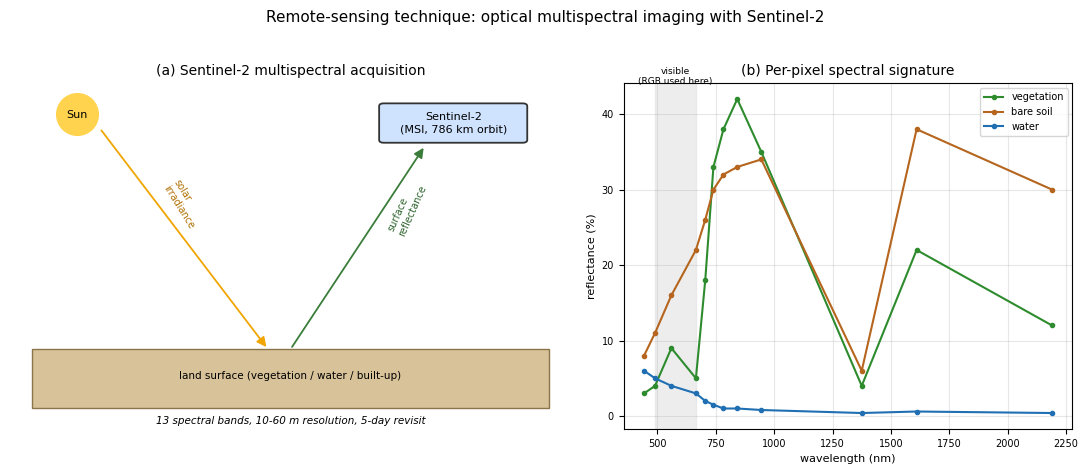

In [ ]:
fig = figures.make_technique_figure("figures/01_sentinel2_technique.png")
plt.show()

## 3. The AI algorithm

A **dual pipeline**: an unsupervised branch (K-means, GMM) that never sees labels, and a
supervised branch (Random Forest on features, CNN on pixels). Running both lets us measure
how much labels — and learned features — actually help.

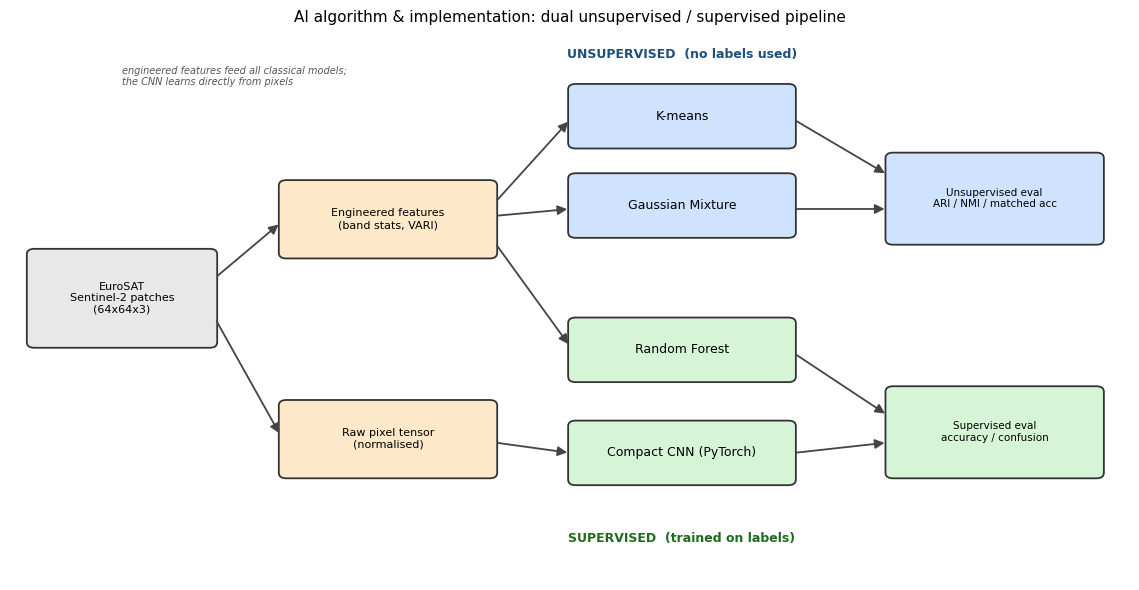

In [ ]:
fig = figures.make_algorithm_figure("figures/02_pipeline_algorithm.png")
plt.show()

## 4. Load the data

`data.get_dataset` downloads EuroSAT from a reliable mirror (cached after the first run) and
falls back to a synthetic Sentinel-2-like dataset if there is no internet.

In [ ]:
t0 = time.time()
if FORCE_SYNTHETIC:
    X, y, class_names = data.make_synthetic(n_per_class=N_PER_CLASS or 300, seed=SEED)
    source = "synthetic"
else:
    X, y, class_names, source = data.get_dataset("data", n_per_class=N_PER_CLASS, seed=SEED)
timings["load_data"] = time.time() - t0

print(f"\nData source : {source}")
print(f"Images      : {X.shape}  (N, H, W, C)")
print(f"Classes     : {len(class_names)}")
print(f"Per class   : {np.bincount(y)}")

  loaded   400 x AnnualCrop
  loaded   400 x Forest


  loaded   400 x HerbaceousVegetation


  loaded   400 x Highway
  loaded   400 x Industrial


  loaded   400 x Pasture


  loaded   400 x PermanentCrop
  loaded   400 x Residential


  loaded   400 x River
  loaded   400 x SeaLake



Data source : eurosat
Images      : (4000, 64, 64, 3)  (N, H, W, C)
Classes     : 10
Per class   : [400 400 400 400 400 400 400 400 400 400]


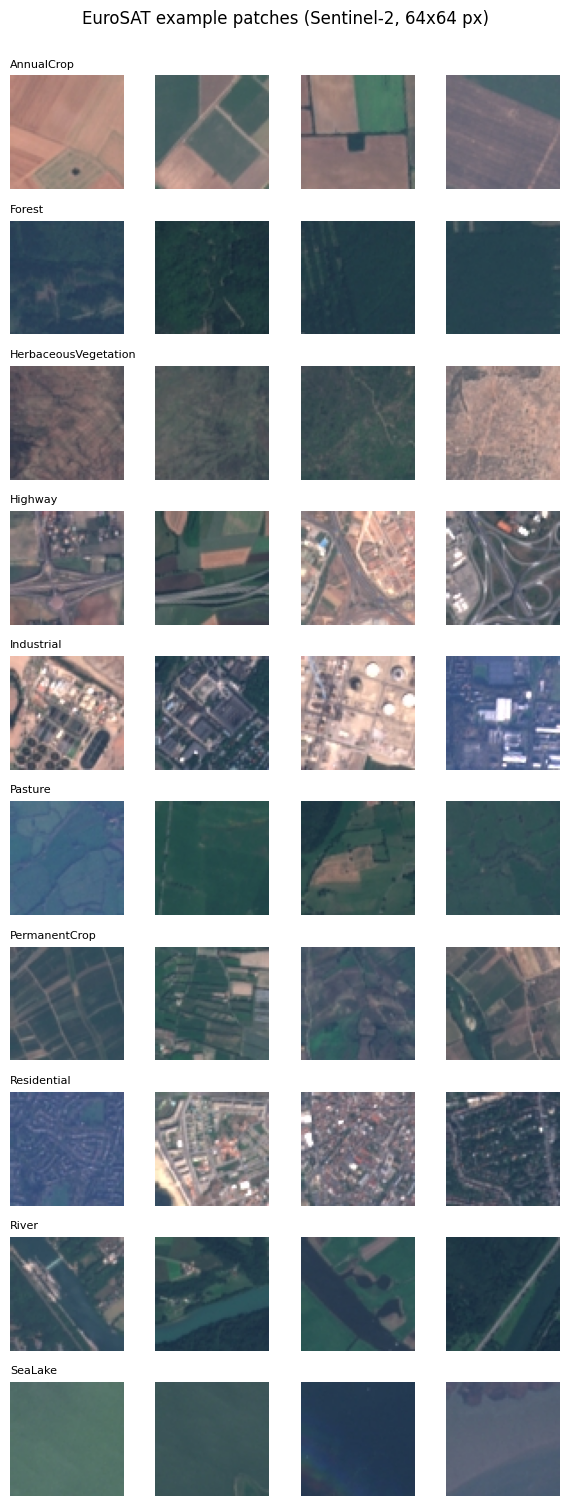

In [ ]:
fig = evaluate.plot_sample_grid(X, y, class_names, n_per_class=4,
                                savepath="figures/03_sample_patches.png")
plt.show()

## 5. Feature engineering (for the classical models)

Each patch is reduced to 9 interpretable numbers — per-band mean & std, the VARI vegetation
index, greenness and brightness — then z-score standardised. The CNN, by contrast, learns
its own features from raw pixels.

In [ ]:
feats, feat_names = features.image_features(X)
print("Feature matrix:", feats.shape, "->", feat_names)
df = pd.DataFrame(feats, columns=feat_names)
df["class"] = [class_names[i] for i in y]
df.groupby("class").mean().round(3)

Feature matrix: (4000, 9) -> ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'VARI', 'greenness', 'brightness']


,mean_R,mean_G,mean_B,std_R,std_G,std_B,VARI,greenness,brightness
class,,,,,,,,,
AnnualCrop,0.497,0.464,0.455,0.150,0.080,0.062,0.007,0.331,0.472
Forest,0.153,0.252,0.298,0.016,0.017,0.011,0.986,0.358,0.234
HerbaceousVegetation,0.395,0.395,0.414,0.078,0.056,0.046,0.061,0.329,0.401
Highway,0.345,0.380,0.407,0.116,0.081,0.071,0.208,0.338,0.377
Industrial,0.481,0.489,0.521,0.187,0.160,0.150,0.038,0.328,0.497
Pasture,0.243,0.347,0.372,0.052,0.034,0.026,0.522,0.363,0.321
PermanentCrop,0.478,0.459,0.452,0.118,0.081,0.065,0.005,0.332,0.463
Residential,0.402,0.413,0.447,0.102,0.078,0.073,0.079,0.328,0.421
River,0.268,0.343,0.381,0.099,0.072,0.057,0.416,0.347,0.330


## 6. Unsupervised learning — K-means & Gaussian Mixture Model

No labels are used to fit these models. Afterwards we align the discovered clusters to the
true classes with the **Hungarian algorithm** and score them with ARI, NMI and matched accuracy.
First, two standard ways to choose the number of clusters: the K-means **elbow** and the GMM **BIC**.

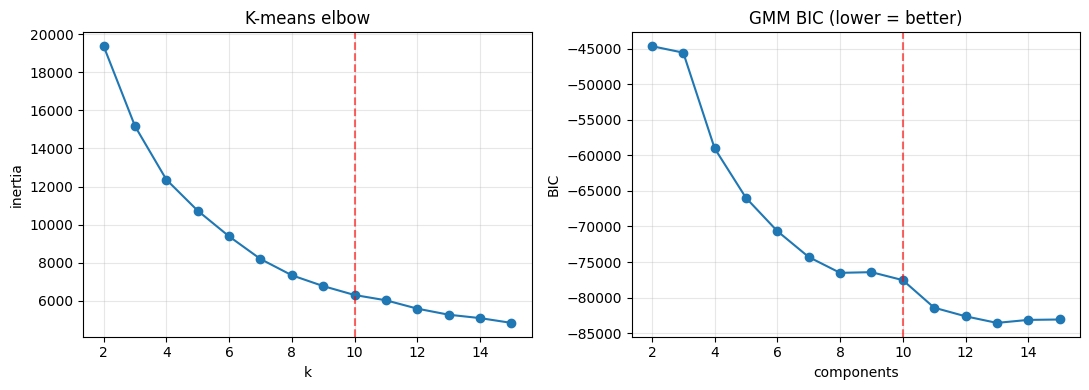

Red line = 10, the true number of classes.


In [ ]:
feats_scaled = features.standardize(feats)[1]   # fit+transform on all (unsupervised)

ks, inertias = unsupervised.kmeans_elbow(feats_scaled, k_range=range(2, 16), seed=SEED)
kb, bics     = unsupervised.gmm_bic(feats_scaled, k_range=range(2, 16), seed=SEED)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertias, "o-"); ax[0].axvline(10, ls="--", c="r", alpha=.6)
ax[0].set(title="K-means elbow", xlabel="k", ylabel="inertia"); ax[0].grid(alpha=.3)
ax[1].plot(kb, bics, "o-");      ax[1].axvline(10, ls="--", c="r", alpha=.6)
ax[1].set(title="GMM BIC (lower = better)", xlabel="components", ylabel="BIC"); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig("figures/04c_elbow_bic.png", dpi=150, bbox_inches="tight"); plt.show()
print("Red line = 10, the true number of classes.")

In [ ]:
t0 = time.time()
km_labels, _  = unsupervised.run_kmeans(feats_scaled, n_clusters=len(class_names), seed=SEED)
gmm_labels, _ = unsupervised.run_gmm(feats_scaled, n_components=len(class_names), seed=SEED)
timings["unsupervised"] = time.time() - t0

km_scores  = evaluate.clustering_scores(km_labels, y)
gmm_scores = evaluate.clustering_scores(gmm_labels, y)
print("K-means:", {k: round(v, 3) for k, v in km_scores.items()})
print("GMM    :", {k: round(v, 3) for k, v in gmm_scores.items()})

K-means: {'ARI': 0.181, 'NMI': 0.319, 'matched_accuracy': 0.364}
GMM    : {'ARI': 0.188, 'NMI': 0.333, 'matched_accuracy': 0.376}


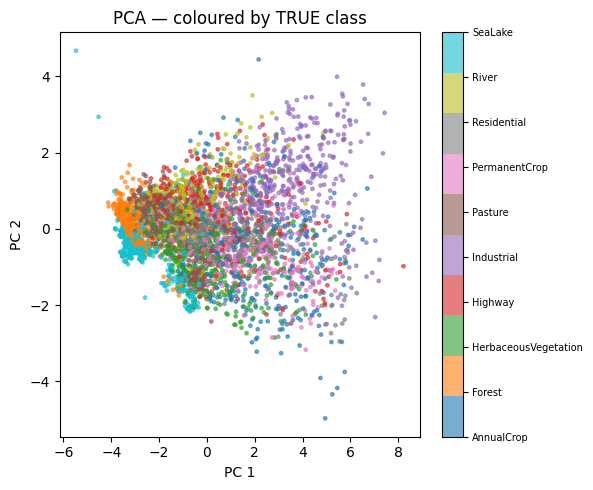

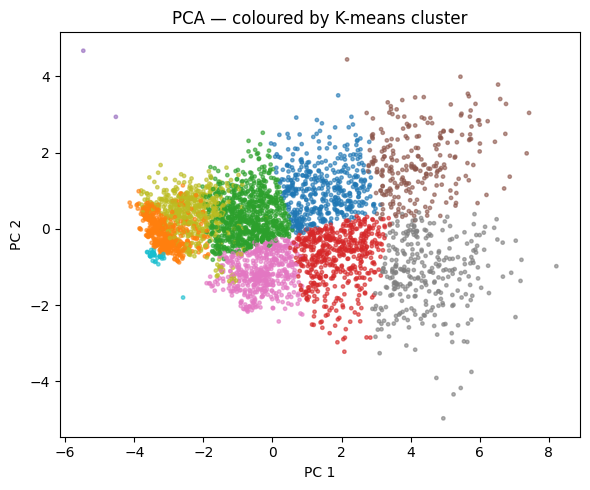

In [ ]:
# Visualise in 2-D PCA space: true classes vs the K-means clusters.
coords, _ = features.pca_2d(feats_scaled, seed=SEED)
evaluate.plot_clusters_2d(coords, y, "PCA — coloured by TRUE class", class_names,
                          savepath="figures/04a_pca_true.png"); plt.show()
evaluate.plot_clusters_2d(coords, km_labels, "PCA — coloured by K-means cluster",
                          savepath="figures/04b_pca_kmeans.png"); plt.show()

**Reading the result:** clustering finds genuine structure (water and forest separate well),
but the green vegetation classes overlap in colour space, capping matched accuracy. This
motivates the supervised models — and especially the CNN, which can use spatial texture.

## 7. Supervised learning — Random Forest

We now use labels. Stratified **60/15/25 train/validation/test** split: the Random Forest
trains on the training features and is scored on the held-out **test** set.

In [ ]:
# Train / val / test split (val is used later for CNN model selection).
Xtr, Xte, ytr, yte, Ftr, Fte = train_test_split(
    X, y, feats, test_size=0.25, stratify=y, random_state=SEED)
Xtr, Xva, ytr, yva, Ftr, Fva = train_test_split(
    Xtr, ytr, Ftr, test_size=0.20, stratify=ytr, random_state=SEED)
scaler, Ftr_s, Fva_s, Fte_s = features.standardize(Ftr, Fva, Fte)
print(f"train={len(ytr)}  val={len(yva)}  test={len(yte)}")

t0 = time.time()
rf = supervised.train_random_forest(Ftr_s, ytr, seed=SEED)
timings["random_forest"] = time.time() - t0
rf_pred = rf.predict(Fte_s)
rf_scores = evaluate.supervised_scores(yte, rf_pred, class_names)
print(f"Random Forest test accuracy: {rf_scores['accuracy']:.3f}")

train=2400  val=600  test=1000


Random Forest test accuracy: 0.712


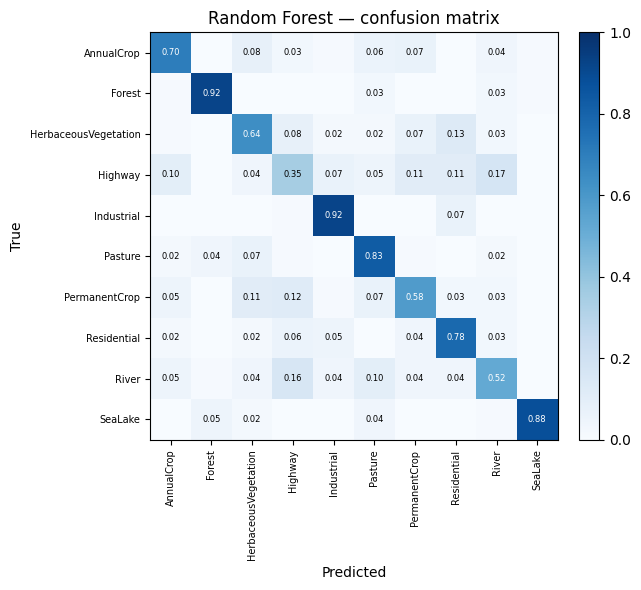

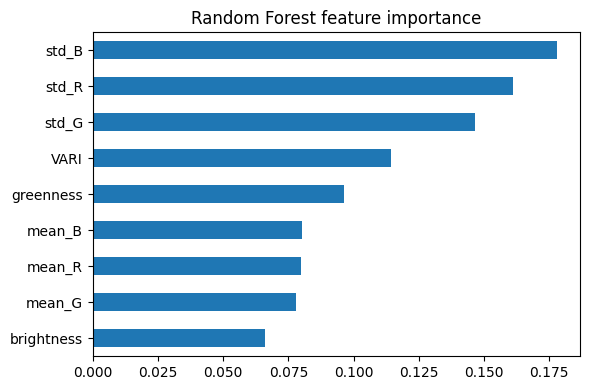

In [ ]:
evaluate.plot_confusion(yte, rf_pred, class_names, "Random Forest — confusion matrix",
                        savepath="figures/05_rf_confusion.png"); plt.show()

# Which engineered features matter most?
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
imp.plot.barh(ax=ax); ax.set_title("Random Forest feature importance"); fig.tight_layout()
fig.savefig("figures/05b_rf_importance.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Supervised learning — compact CNN

A small PyTorch CNN learns features directly from the raw 3×64×64 pixels. It trains with Adam
and a cosine learning-rate schedule; the best-validation weights are restored before testing.
This is the deep-learning component of the project — kept small enough to train on a CPU.

In [ ]:
t0 = time.time()
with carbon.track_energy("cnn_train") as t_cnn:
    model, hist = supervised.train_cnn(
        Xtr, ytr, Xva, yva, n_classes=len(class_names),
        epochs=CNN_EPOCHS, seed=SEED)
timings["cnn_train"] = time.time() - t0

cnn_eval = supervised.evaluate_cnn(model, Xte, yte)
n_params = supervised.count_parameters(model)
print(f"\nCNN parameters     : {n_params:,}")
print(f"CNN test accuracy  : {cnn_eval['accuracy']:.3f}")
print(f"Best val accuracy  : {hist['best_val_acc']:.3f}")

  epoch  1/20  train_loss=1.811  val_acc=0.262


  epoch  2/20  train_loss=1.470  val_acc=0.605


  epoch  3/20  train_loss=1.303  val_acc=0.532


  epoch  4/20  train_loss=1.205  val_acc=0.615


  epoch  5/20  train_loss=1.105  val_acc=0.605


...

  epoch 17/20  train_loss=0.774  val_acc=0.795


  epoch 18/20  train_loss=0.762  val_acc=0.775


  epoch 19/20  train_loss=0.756  val_acc=0.768


  epoch 20/20  train_loss=0.759  val_acc=0.773
  -> restored best-validation weights (val_acc=0.795)



CNN parameters     : 24,458
CNN test accuracy  : 0.772
Best val accuracy  : 0.795


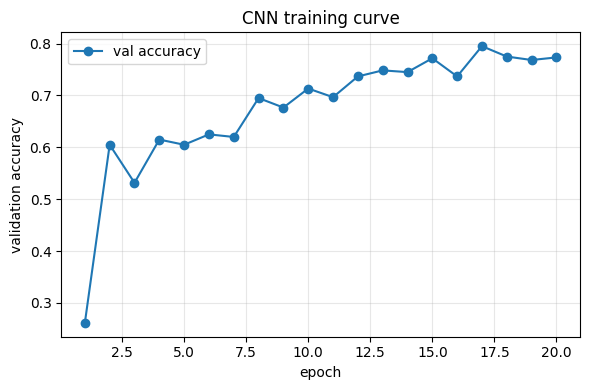

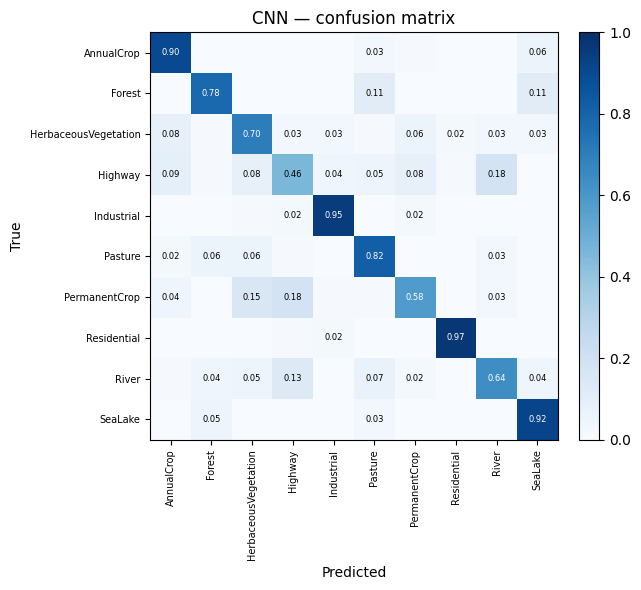

In [ ]:
# Training curve + confusion matrix.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(hist["val_acc"]) + 1), hist["val_acc"], "o-", label="val accuracy")
ax.set(xlabel="epoch", ylabel="validation accuracy", title="CNN training curve")
ax.grid(alpha=.3); ax.legend(); fig.tight_layout()
fig.savefig("figures/07_cnn_curve.png", dpi=150, bbox_inches="tight"); plt.show()

evaluate.plot_confusion(cnn_eval["y_true"], cnn_eval["y_pred"], class_names,
                        "CNN — confusion matrix", savepath="figures/06_cnn_confusion.png"); plt.show()

## 9. Head-to-head comparison

,method,type,metric,score
0,K-means,unsupervised,matched acc.,0.364
1,Gaussian Mixture,unsupervised,matched acc.,0.376
2,Random Forest,supervised,test acc.,0.712
3,Compact CNN,supervised,test acc.,0.772


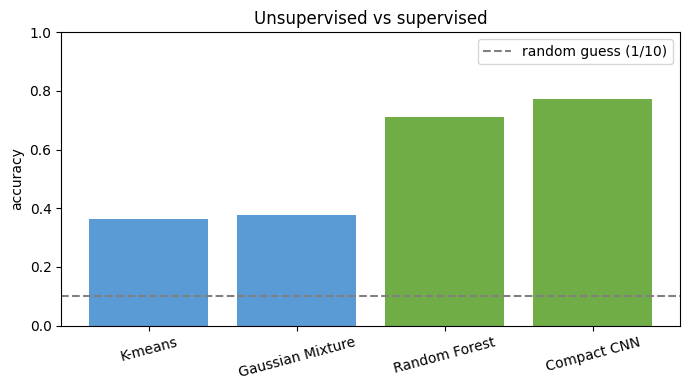

In [ ]:
comparison = pd.DataFrame([
    {"method": "K-means",          "type": "unsupervised", "metric": "matched acc.", "score": km_scores["matched_accuracy"]},
    {"method": "Gaussian Mixture", "type": "unsupervised", "metric": "matched acc.", "score": gmm_scores["matched_accuracy"]},
    {"method": "Random Forest",    "type": "supervised",   "metric": "test acc.",    "score": rf_scores["accuracy"]},
    {"method": "Compact CNN",      "type": "supervised",   "metric": "test acc.",    "score": cnn_eval["accuracy"]},
]).round(3)
display(comparison)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#5b9bd5" if t == "unsupervised" else "#70ad47" for t in comparison["type"]]
ax.bar(comparison["method"], comparison["score"], color=colors)
ax.axhline(0.1, ls="--", c="grey", label="random guess (1/10)")
ax.set_ylabel("accuracy"); ax.set_title("Unsupervised vs supervised"); ax.set_ylim(0, 1)
ax.legend(); plt.xticks(rotation=15); fig.tight_layout()
fig.savefig("figures/08_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

**Takeaway:** supervised beats unsupervised, and the CNN beats the feature-based Random Forest —
because it exploits spatial texture and context that colour-only features throw away.

## 10. Environmental cost of this run

We estimate energy and CO₂ from wall-clock time, CPU power draw, facility overhead (PUE) and
grid carbon intensity — the same method as CodeCarbon, implemented transparently in
`src/carbon.py`. **Edit the parameters for your machine and electricity grid.** Full discussion:
[`docs/ENVIRONMENTAL_COST.md`](../docs/ENVIRONMENTAL_COST.md).

In [ ]:
total_seconds = sum(timings.values())
report = carbon.estimate_energy(
    total_seconds,
    grid_intensity=230.0,   # gCO2/kWh — UK 2023 avg; change for your region
)
print("Per-step wall-clock (s):")
for k, v in timings.items():
    print(f"  {k:16s}: {v:7.1f}")
print(f"  {'TOTAL':16s}: {total_seconds:7.1f}\n")
print(report.summary())

# Persist a machine-readable record alongside the metrics.
results = {
    "data_source": source, "n_samples": int(len(y)), "n_per_class": N_PER_CLASS,
    "kmeans": km_scores, "gmm": gmm_scores,
    "random_forest": {"accuracy": rf_scores["accuracy"]},
    "cnn": {"accuracy": cnn_eval["accuracy"], "n_parameters": int(n_params),
            "best_val_acc": hist["best_val_acc"]},
    "timings_seconds": timings,
    "environmental_cost": report.to_dict(),
}
with open("results/metrics_notebook.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved results/metrics_notebook.json")

Per-step wall-clock (s):
  load_data       :     2.3
  unsupervised    :     2.2
  random_forest   :     1.1
  cnn_train       :    93.5
  TOTAL           :    99.0

runtime      :     99.0 s (0.028 h)
energy        :     1.84 Wh (0.00184 kWh)
CO2 emitted   :     0.42 g
  ~= 0.002 km driven in a petrol car
  ~= 0.05 smartphone charges
  ~= 0.006 kettles boiled

Saved results/metrics_notebook.json


## 11. Conclusions

- **Unsupervised** clustering (K-means, GMM) recovers coarse land-cover structure but is
  limited where classes overlap spectrally — matched accuracy well below the supervised models.
- **Supervised** learning helps a lot; the **CNN** wins by learning spatial features from raw
  pixels rather than relying on hand-crafted colour statistics.
- The **environmental cost** of the whole run is on the order of a few grams of CO₂ — small,
  but worth measuring and reporting, and dominated by CNN training.

**Possible extensions:** use the 13-band multispectral product (true NDVI/NDWI), add data
augmentation, try transfer learning from a pretrained EO model, or extend to pixel-level
segmentation. See [`report/REPORT.md`](../report/REPORT.md).